# Pakistan Petrol Price Analytics & Forecasting

## 1. Objective

This project analyzes the relationship between petrol prices in
Pakistan, international crude oil prices, and the USD/PKR exchange rate.

## Main Research Question

How do international crude oil prices and the USD/PKR exchange rate
influence petrol prices in Pakistan?

## Key Questions

1. How have petrol prices in Pakistan changed over time?
2. How closely are Pakistani petrol prices related to Brent crude oil?
3. How does the USD/PKR exchange rate affect petrol prices?
4. Is there a time lag between changes in crude oil prices and petrol prices?
5. Which factor has the strongest relationship with petrol prices?
6. Can petrol prices be estimated using crude oil prices and USD/PKR?
7. How accurately can we forecast future petrol prices?
8. What happens to estimated petrol prices under different crude oil scenarios?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import yfinance as yf
import statsmodels.api as sm

## 2. Collecting Historical Petrol Price Data

The historical petrol-price data is obtained from the ek litre archive,
which preserves PSO fuel-price notifications dating back to 2006.

The data contains the effective date and notified prices for different
fuel products. For this project, we will use the petrol price as our
main target variable.

In [2]:
# URL of the historical petrol-price data
historical_petrol_url = "https://eklitre.pk/data/notified-prices.json"

# Download the JSON data
response = requests.get(historical_petrol_url)

# Make sure the request was successful
response.raise_for_status()

# Convert the JSON response into Python data
historical_petrol_data = response.json()

print("Historical petrol price data downloaded successfully.")

Historical petrol price data downloaded successfully.


In [3]:
# Look at the main parts of the downloaded data
historical_petrol_data.keys()

dict_keys(['version', 'source', 'columns', 'snapshots', 'snapshot_documents', 'snapshots_note', 'contradicted', 'disputed', 'concerns_count', 'concerns', 'notifications'])

In [4]:
print(historical_petrol_data)

{'version': 4, 'source': 'https://psopk.com/fuel-prices/pol/archives', 'columns': ['effective_date', 'petrol', 'diesel', 'kerosene', 'light_diesel', 'snapshot'], 'snapshots': ['a6b6d68a60f765f6313c10a35a8e6ddee140ca34c990c012b5b10c6c33fbefba', 'f4e2b7e699cd567aa1d8ab0d3f61f792a5ec2684327a53a25df1bb40a50604d9', '3e206eeda57a7ff4f8706d725e1677cab50de0e84af7627763c27a5e789a79c0', '830cfaf2a8fec1028d5df27134b0a243be949d318c53e4f200aa62ce89f886bf', '51f3b1a864d9e4ee38ac1ef329a126a71781a3e882d08d8eed49834929c59c71', '2cecbea6cddf39e2d1815a4aa70347139cc8c3755a69a664287fb2feabf73833', '63cb1d6983421a2de6acd50a81f0a3c8b10c0faa2be2c37e9a66b9cc11a0bf08', '0ad202813b502dbc94ba970446aee14c2a686fb544fd25a05d34217bf0efafc7', '6a70663a6d6c1dc094ddde3704398412e85764dd97b4b5f813bd7a118186c816', 'b03ba0d58bb88995368ab8faf5c5a023aa05c0255ff5c79e08fd0db455aaad9b', '494a0a25bb49554620201c587517ef25cb5cbd27c2d4b25a08ce5908b71744d9', 'f71c5dc381c4fcdcad6f92c0782ff9717f648dd3d354dedddffc63edb68825e0', '11fab74

In [5]:
# Get the historical notifications from the downloaded JSON
notifications = historical_petrol_data["notifications"]

# Create a DataFrame using the column names provided by the source
petrol_history = pd.DataFrame(
    notifications,
    columns=historical_petrol_data["columns"]
)

# Convert the date column into a proper date format
petrol_history["effective_date"] = pd.to_datetime(
    petrol_history["effective_date"]
)

# Sort the data from oldest to newest
petrol_history = petrol_history.sort_values("effective_date").reset_index(drop=True)

print(f"Total historical records: {len(petrol_history)}")

Total historical records: 420


In [6]:
# Show the first few historical petrol prices
petrol_history.head(10)

,effective_date,petrol,diesel,kerosene,light_diesel,snapshot
0,2006-01-01,103.36,107.00,77.95,98.74,0
1,2006-01-01,87.41,94.15,85.76,83.52,0
2,2006-01-01,83.71,92.10,84.65,88.30,1
3,2006-01-01,62.13,62.65,59.35,54.94,2
4,2006-01-09,55.00,65.00,33.00,56.00,3
5,2006-05-01,55.55,37.29,NaN,NaN,3
6,2006-05-15,55.00,65.00,33.00,56.00,3
7,2006-05-16,55.55,37.29,NaN,NaN,3
8,2006-06-01,55.55,37.29,NaN,NaN,3
9,2006-06-16,55.55,37.29,NaN,NaN,3


In [7]:
# Check the structure and data types
petrol_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   effective_date  420 non-null    datetime64[us]
 1   petrol          418 non-null    float64       
 2   diesel          418 non-null    float64       
 3   kerosene        318 non-null    float64       
 4   light_diesel    301 non-null    float64       
 5   snapshot        420 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 19.8 KB


In [8]:
# Check the size of our historical dataset
print(f"Rows: {len(petrol_history)}")
print(f"Columns: {len(petrol_history.columns)}")

# Check the date range
print(f"Start date: {petrol_history['effective_date'].min().date()}")
print(f"End date: {petrol_history['effective_date'].max().date()}")

Rows: 420
Columns: 6
Start date: 2006-01-01
End date: 2026-09-10


In [9]:
# Check for missing values
petrol_history.isna().sum()

effective_date      0
petrol              2
diesel              2
kerosene          102
light_diesel      119
snapshot            0
dtype: int64

In [10]:
# Check how many different petrol prices we have
petrol_history["petrol"].nunique()

268

In [11]:
# We only need the date and petrol price for this project
petrol_history = petrol_history[["effective_date", "petrol"]].copy()

# Check the updated dataset
petrol_history.head()

,effective_date,petrol
0,2006-01-01,103.36
1,2006-01-01,87.41
2,2006-01-01,83.71
3,2006-01-01,62.13
4,2006-01-09,55.00


In [12]:
# Check the remaining missing petrol prices
print("Missing petrol prices:", petrol_history["petrol"].isna().sum())

# Check for duplicate dates
print("Duplicate dates:", petrol_history["effective_date"].duplicated().sum())

Missing petrol prices: 2
Duplicate dates: 6


In [13]:
# Find dates that appear more than once
duplicate_dates = petrol_history[
    petrol_history["effective_date"].duplicated(keep=False)
].sort_values("effective_date")

duplicate_dates

,effective_date,petrol
0,2006-01-01,103.36
1,2006-01-01,87.41
2,2006-01-01,83.71
3,2006-01-01,62.13
121,2012-10-22,101.42
122,2012-10-22,101.08
141,2014-03-01,70.29
142,2014-03-01,110.03
148,2014-09-01,106.56
149,2014-09-01,106.56


In [14]:
# Show the records where petrol price is missing
petrol_history[petrol_history["petrol"].isna()]

,effective_date,petrol
165,2015-12-23,NaN
171,2016-05-02,NaN


In [15]:
# Recreate the full notification table so we can inspect the snapshot IDs
all_notifications = pd.DataFrame(
    historical_petrol_data["notifications"],
    columns=historical_petrol_data["columns"]
)

# Convert the date column
all_notifications["effective_date"] = pd.to_datetime(
    all_notifications["effective_date"]
)

# Show duplicate dates with all available information
duplicate_dates_full = all_notifications[
    all_notifications["effective_date"].duplicated(keep=False)
].sort_values(["effective_date", "snapshot"])

duplicate_dates_full

,effective_date,petrol,diesel,kerosene,light_diesel,snapshot
0,2006-01-01,103.36,107.00,77.95,98.74,0
1,2006-01-01,87.41,94.15,85.76,83.52,0
2,2006-01-01,83.71,92.10,84.65,88.30,1
3,2006-01-01,62.13,62.65,59.35,54.94,2
121,2012-10-22,101.42,110.13,98.91,NaN,11
122,2012-10-22,101.08,113.29,103.00,97.68,11
142,2014-03-01,110.03,116.75,106.76,100.22,14
141,2014-03-01,70.29,80.61,61.44,57.94,15
148,2014-09-01,106.56,108.34,96.99,92.08,15
149,2014-09-01,106.56,108.34,96.99,NaN,15


In [16]:
# Look at the full records around the two missing petrol prices
missing_petrol = all_notifications[
    all_notifications["petrol"].isna()
]

missing_petrol

,effective_date,petrol,diesel,kerosene,light_diesel,snapshot
165,2015-12-23,NaN,NaN,NaN,NaN,17
171,2016-05-02,NaN,NaN,NaN,NaN,17


In [17]:
# Remove rows where the petrol price is completely missing
petrol_history = petrol_history.dropna(subset=["petrol"]).copy()

# Remove exact duplicate rows
petrol_history = petrol_history.drop_duplicates().copy()

# Sort everything by date again
petrol_history = petrol_history.sort_values("effective_date").reset_index(drop=True)

print(f"Rows after cleaning: {len(petrol_history)}")
print(f"Missing petrol prices: {petrol_history['petrol'].isna().sum()}")

Rows after cleaning: 417
Missing petrol prices: 0


In [18]:
# Check whether any dates still appear more than once
remaining_duplicates = petrol_history[
    petrol_history["effective_date"].duplicated(keep=False)
].sort_values("effective_date")

remaining_duplicates

,effective_date,petrol
0,2006-01-01,103.36
1,2006-01-01,87.41
2,2006-01-01,83.71
3,2006-01-01,62.13
121,2012-10-22,101.42
122,2012-10-22,101.08
141,2014-03-01,110.03
142,2014-03-01,70.29


## 3. Petrol Price Trend

The historical petrol-price series is based on notified pump prices.
Because each notification remains in effect until the next notification,
the series is treated as a step-like time series rather than an averaged
daily series.

The first visualization shows how petrol prices in Pakistan have changed
over the historical period.

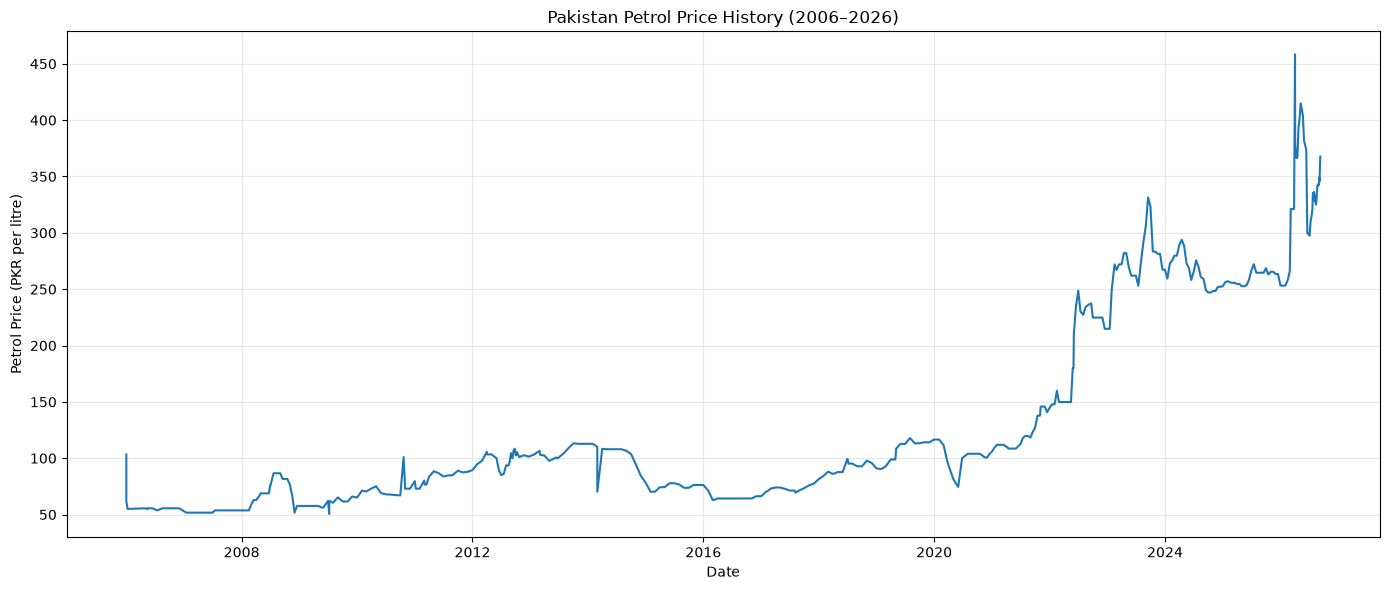

In [19]:
# Plot the historical petrol price trend

plt.figure(figsize=(14, 6))

plt.plot(
    petrol_history["effective_date"],
    petrol_history["petrol"],
    linewidth=1.5
)

plt.title("Pakistan Petrol Price History (2006–2026)")
plt.xlabel("Date")
plt.ylabel("Petrol Price (PKR per litre)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 4. Major Petrol Price Changes

Before examining the relationship with international crude oil prices,
we identify the largest increases and decreases in Pakistan's notified
petrol prices.

This helps highlight periods of major price movements that can later
be compared with changes in crude oil prices and the USD/PKR exchange rate.

In [20]:
# Calculate the change from one petrol notification to the next
petrol_history["price_change"] = petrol_history["petrol"].diff()

# Find the 10 largest price increases
largest_increases = petrol_history.nlargest(10, "price_change")

largest_increases[["effective_date", "petrol", "price_change"]]

,effective_date,petrol,price_change
366,2026-04-03,458.41,137.24
362,2026-03-07,321.17,55.00
143,2014-04-01,108.31,38.02
287,2023-01-29,249.80,35.00
83,2010-10-22,101.08,34.09
269,2022-05-27,179.86,30.00
271,2022-06-03,209.86,30.00
370,2026-04-25,393.35,26.77
302,2023-09-16,331.38,26.02
224,2020-06-26,100.11,25.59


In [21]:
# Find the 10 largest price decreases
largest_decreases = petrol_history.nsmallest(10, "price_change")

largest_decreases[["effective_date", "petrol", "price_change"]]

,effective_date,petrol,price_change
367,2026-04-04,378.41,-80.00
378,2026-06-20,299.50,-74.28
304,2023-10-16,283.38,-40.00
142,2014-03-01,70.29,-39.74
84,2010-11-01,72.96,-28.12
375,2026-05-30,381.78,-22.00
3,2006-01-01,62.13,-21.58
274,2022-07-15,230.24,-18.50
1,2006-01-01,87.41,-15.95
318,2024-05-16,273.10,-15.39


In [22]:
# Remove the temporary analysis column from the main dataset
petrol_history = petrol_history.drop(columns=["price_change"])

# Check our clean dataset
petrol_history.head()

,effective_date,petrol
0,2006-01-01,103.36
1,2006-01-01,87.41
2,2006-01-01,83.71
3,2006-01-01,62.13
4,2006-01-09,55.00


In [23]:
print(f"Final petrol observations: {len(petrol_history)}")
print(f"Missing values: {petrol_history.isna().sum().sum()}")

Final petrol observations: 417
Missing values: 0


## 5. International Brent Crude Oil Prices

Brent crude oil is used as the international oil-price indicator in this
project.

The data is sourced from the U.S. Energy Information Administration (EIA)
and contains daily Europe Brent spot prices in US dollars per barrel.

Brent prices will later be compared with Pakistan's petrol prices to
investigate how changes in international crude oil prices are associated
with domestic fuel prices.

In [24]:
# URL of the EIA Brent crude oil Excel data
brent_url = "https://www.eia.gov/dnav/pet/hist_xls/RBRTEd.xls"

In [25]:
# Read the actual Brent price data from the "Data 1" worksheet
brent_data = pd.read_excel(
    brent_url,
    sheet_name="Data 1"
)

print("Brent crude oil data downloaded successfully.")

Brent crude oil data downloaded successfully.


In [26]:
brent_data.head(10)

,Back to Contents,Data 1: Europe Brent Spot Price FOB (Dollars per Barrel)
0,Sourcekey,RBRTE
1,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
2,1987-05-20 00:00:00,18.63
3,1987-05-21 00:00:00,18.45
4,1987-05-22 00:00:00,18.55
5,1987-05-25 00:00:00,18.6
6,1987-05-26 00:00:00,18.63
7,1987-05-27 00:00:00,18.6
8,1987-05-28 00:00:00,18.6
9,1987-05-29 00:00:00,18.58


In [27]:
brent_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9969 entries, 0 to 9968
Data columns (total 2 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Back to Contents                                          9969 non-null   object
 1   Data 1: Europe Brent Spot Price FOB (Dollars per Barrel)  9969 non-null   object
dtypes: object(2)
memory usage: 155.9+ KB


In [28]:
# Rename the columns to something easier to work with
brent_data.columns = ["date", "brent_price"]

# Remove the two header rows inside the worksheet
brent_data = brent_data.iloc[2:].copy()

# Convert the date column to datetime
brent_data["date"] = pd.to_datetime(brent_data["date"])

# Convert Brent prices from text to numbers
brent_data["brent_price"] = pd.to_numeric(
    brent_data["brent_price"],
    errors="coerce"
)

# Remove any rows where the date or price is missing
brent_data = brent_data.dropna(
    subset=["date", "brent_price"]
).reset_index(drop=True)

print(f"Brent observations: {len(brent_data)}")

Brent observations: 9967


In [29]:
brent_data.head()

,date,brent_price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [30]:
brent_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9967 entries, 0 to 9966
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         9967 non-null   datetime64[us]
 1   brent_price  9967 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 155.9 KB


## 5.1 Aligning the Brent Data

The Brent dataset contains historical observations from 1987 onward.
Since the Pakistani petrol-price dataset begins in 2006, only Brent
observations from 2006 onward are required for this project.

In [31]:
# Keep only Brent prices from the beginning of our petrol dataset onward
brent_data = brent_data[
    brent_data["date"] >= petrol_history["effective_date"].min()
].copy()

# Reset the row numbers
brent_data = brent_data.reset_index(drop=True)

print(f"Brent observations for our project: {len(brent_data)}")
print(f"Start date: {brent_data['date'].min().date()}")
print(f"End date: {brent_data['date'].max().date()}")

Brent observations for our project: 5226
Start date: 2006-01-03
End date: 2026-09-01


In [32]:
brent_data.head()

,date,brent_price
0,2006-01-03,61.51
1,2006-01-04,61.25
2,2006-01-05,61.68
3,2006-01-06,62.43
4,2006-01-09,62.51


## 6. USD/PKR Exchange Rate

The USD/PKR exchange rate is included because international crude oil
prices are denominated in US dollars, while petrol prices in Pakistan
are expressed in Pakistani rupees.

Daily USD/PKR exchange-rate data is obtained from Yahoo Finance and
aggregated into monthly averages. Using monthly averages allows the
exchange-rate data to be aligned with the monthly analysis used in this
project.

The exchange rate will be used to examine how currency movements,
together with international crude oil prices, are associated with
changes in petrol prices in Pakistan.


In [33]:
# Download daily USD/PKR exchange-rate data
usd_pkr = yf.download(
    "PKR=X",
    start="2006-01-01",
    end="2026-09-10",
    auto_adjust=False
)

print(f"Daily observations: {len(usd_pkr)}")
print(usd_pkr.head())

[*********************100%***********************]  1 of 1 completed

Daily observations: 5354
Price       Adj Close      Close       High        Low       Open Volume
Ticker          PKR=X      PKR=X      PKR=X      PKR=X      PKR=X  PKR=X
Date                                                                    
2006-01-02  59.799999  59.799999  59.900002  59.700001  59.799999      0
2006-01-03  59.840000  59.840000  59.939999  59.680000  59.799999      0
2006-01-04  59.840000  59.840000  59.939999  59.650002  59.840000      0
2006-01-06  59.840000  59.840000  59.939999  59.689999  59.840000      0
2006-01-09  59.919998  59.919998  60.040001  59.700001  59.939999      0


In [34]:
# Keep only the exchange-rate closing price
usd_pkr = usd_pkr[["Close"]].copy()

# Rename the column
usd_pkr.columns = ["usd_pkr"]

# Remove missing values
usd_pkr = usd_pkr.dropna()

print(usd_pkr.head())
print(usd_pkr.tail())

              usd_pkr
Date                 
2006-01-02  59.799999
2006-01-03  59.840000
2006-01-04  59.840000
2006-01-06  59.840000
2006-01-09  59.919998
               usd_pkr
Date                  
2026-09-03  277.250000
2026-09-04  277.250000
2026-09-07  275.930389
2026-09-08  269.273743
2026-09-09  277.149994


In [35]:
# Make sure the index is a datetime index
usd_pkr.index = pd.to_datetime(usd_pkr.index)

# Calculate the average USD/PKR exchange rate for each month
usd_pkr_monthly = (
    usd_pkr["usd_pkr"]
    .resample("MS")
    .mean()
    .reset_index()
)

usd_pkr_monthly.columns = ["date", "usd_pkr"]

print(f"Monthly observations: {len(usd_pkr_monthly)}")
print(usd_pkr_monthly.head())

Monthly observations: 249
        date    usd_pkr
0 2006-01-01  59.874687
1 2006-02-01  59.945000
2 2006-03-01  60.063334
3 2006-04-01  60.063611
4 2006-05-01  59.975526


In [36]:
# Check the cleaned monthly USD/PKR data

print("First month:", usd_pkr_monthly["date"].min().date())
print("Last month:", usd_pkr_monthly["date"].max().date())
print("Missing values:", usd_pkr_monthly["usd_pkr"].isna().sum())

print("\nLast 5 months:")
print(usd_pkr_monthly.tail())

First month: 2006-01-01
Last month: 2026-09-01
Missing values: 0

Last 5 months:
          date     usd_pkr
244 2026-05-01  277.757879
245 2026-06-01  277.275722
246 2026-07-01  277.110077
247 2026-08-01  276.666302
248 2026-09-01  275.535575


## 7. Monthly Brent Crude Oil Prices

Brent crude oil prices are available as daily observations from the
U.S. Energy Information Administration (EIA).

Since the USD/PKR exchange-rate data is being analyzed at a monthly
frequency, the daily Brent prices will also be aggregated into monthly
averages.

This creates a consistent monthly dataset for examining the
relationship between international crude oil prices, the USD/PKR
exchange rate, and petrol prices in Pakistan.


In [37]:
# Calculate monthly average Brent crude oil prices

brent_monthly = (
    brent_data
    .set_index("date")["brent_price"]
    .resample("MS")
    .mean()
    .reset_index()
)

brent_monthly.columns = ["date", "brent_price"]

print("Monthly Brent observations:", len(brent_monthly))
print(brent_monthly.head())

Monthly Brent observations: 249
        date  brent_price
0 2006-01-01    62.985238
1 2006-02-01    60.210000
2 2006-03-01    62.064783
3 2006-04-01    70.260000
4 2006-05-01    69.776957


## 8. Monthly Petrol Prices

The historical petrol-price data consists of individual price
notifications rather than daily observations.

Each notified price remains effective until the next notification.
Therefore, the notification-based series will first be converted into
a daily price series, with each price carried forward until the next
notification.

The daily petrol prices will then be aggregated into monthly averages.
This provides a consistent monthly petrol-price measure that can be
compared with monthly Brent crude oil prices and the USD/PKR exchange
rate.


In [38]:
# Make a copy of the petrol data
petrol_notifications = petrol_history.copy()

# Sort the notifications by date
petrol_notifications = petrol_notifications.sort_values("effective_date")

# If there is more than one notification on the same date,
# keep the last one recorded for that date
petrol_notifications = petrol_notifications.drop_duplicates(
    subset="effective_date",
    keep="last"
)

# Create a date for every day in our data period
all_dates = pd.date_range(
    start=petrol_notifications["effective_date"].min(),
    end=petrol_notifications["effective_date"].max(),
    freq="D"
)

daily_dates = pd.DataFrame({"date": all_dates})

# Match each day with the most recent petrol price notification
petrol_daily = pd.merge_asof(
    daily_dates,
    petrol_notifications.rename(
        columns={"effective_date": "date"}
    ),
    on="date",
    direction="backward"
)

print("Daily petrol observations:", len(petrol_daily))
print(petrol_daily.head())

Daily petrol observations: 7558
        date  petrol
0 2006-01-01   62.13
1 2006-01-02   62.13
2 2006-01-03   62.13
3 2006-01-04   62.13
4 2006-01-05   62.13


## 9. Monthly Petrol Price Averages

The daily petrol-price series is now aggregated into monthly averages.

Using monthly averages allows petrol prices to be compared consistently
with the monthly Brent crude oil prices and USD/PKR exchange rates.

This monthly dataset will be used for the correlation, regression,
lag analysis, and forecasting stages of the project.


In [39]:
# Calculate the monthly average petrol price

petrol_monthly = (
    petrol_daily
    .set_index("date")["petrol"]
    .resample("MS")
    .mean()
    .reset_index()
)

petrol_monthly.columns = ["date", "petrol_price"]

print("Monthly petrol observations:", len(petrol_monthly))
print(petrol_monthly.head())

Monthly petrol observations: 249
        date  petrol_price
0 2006-01-01     56.840000
1 2006-02-01     55.000000
2 2006-03-01     55.000000
3 2006-04-01     55.000000
4 2006-05-01     55.532258


## 10. Combined Monthly Dataset

The three datasets have now been converted to a monthly frequency:

* Petrol price in Pakistan
* Brent crude oil price
* USD/PKR exchange rate

They will now be combined using the month as the common date.

This combined dataset will form the basis for the statistical analysis,
including correlation analysis, lag analysis, regression, forecasting,
and scenario analysis.


In [40]:
# Combine the three monthly datasets

monthly_data = petrol_monthly.merge(
    brent_monthly,
    on="date",
    how="inner"
)

monthly_data = monthly_data.merge(
    usd_pkr_monthly,
    on="date",
    how="inner"
)

# Sort the data by date
monthly_data = monthly_data.sort_values("date").reset_index(drop=True)

print("Total monthly observations:", len(monthly_data))
print("Date range:", monthly_data["date"].min().date(), "to", monthly_data["date"].max().date())

print("\nFirst 5 rows:")
print(monthly_data.head())

Total monthly observations: 249
Date range: 2006-01-01 to 2026-09-01

First 5 rows:
        date  petrol_price  brent_price    usd_pkr
0 2006-01-01     56.840000    62.985238  59.874687
1 2006-02-01     55.000000    60.210000  59.945000
2 2006-03-01     55.000000    62.064783  60.063334
3 2006-04-01     55.000000    70.260000  60.063611
4 2006-05-01     55.532258    69.776957  59.975526


In [41]:
print("\nMissing values:")
print(monthly_data.isna().sum())


Missing values:
date            0
petrol_price    0
brent_price     0
usd_pkr         0
dtype: int64


## 11. Initial Statistical Overview

Before visualizing the relationships between the variables, we examine
basic descriptive statistics for the combined monthly dataset.

This provides an initial understanding of the average, minimum, maximum,
and variation in petrol prices, Brent crude oil prices, and the USD/PKR
exchange rate over the study period.


In [42]:
# Basic descriptive statistics

monthly_data[[
    "petrol_price",
    "brent_price",
    "usd_pkr"
]].describe()

,petrol_price,brent_price,usd_pkr
count,249.000000,249.000000,249.000000
mean,123.970269,77.364541,156.100016
std,80.812609,23.547796,272.834741
min,51.700000,18.378500,59.874687
25%,70.570000,62.050455,85.420181
50%,94.190000,74.345238,103.936000
75%,117.830000,95.155714,167.159179
max,405.187742,132.718182,4281.130750


## 12. Checking Extreme USD/PKR Values

The descriptive statistics show an unusually high maximum value for the
USD/PKR exchange rate compared with the rest of the dataset.

Before performing correlation and regression analysis, we need to
identify unusually large or small exchange-rate observations and verify
whether they represent genuine market movements or data anomalies.



In [43]:
# Show the highest USD/PKR values

monthly_data[
    ["date", "usd_pkr"]
].sort_values(
    "usd_pkr",
    ascending=False
).head(10)

,date,usd_pkr
63,2011-04-01,4281.130750
212,2023-09-01,297.553743
211,2023-08-01,291.882778
209,2023-06-01,285.980472
208,2023-05-01,284.549644
214,2023-11-01,283.857622
234,2025-07-01,283.694312
207,2023-04-01,283.495229
233,2025-06-01,282.159656
215,2023-12-01,281.985051


In [44]:
# Show the lowest USD/PKR values

monthly_data[
    ["date", "usd_pkr"]
].sort_values(
    "usd_pkr",
    ascending=True
).head(10)

,date,usd_pkr
0,2006-01-01,59.874687
5,2006-06-01,59.910909
1,2006-02-01,59.945000
4,2006-05-01,59.975526
2,2006-03-01,60.063334
3,2006-04-01,60.063611
7,2006-08-01,60.126364
6,2006-07-01,60.225238
18,2007-07-01,60.249091
19,2007-08-01,60.271304


## 13. Handling an Exchange Rate Data Anomaly

During the data-quality check, one monthly USD/PKR observation was found
to be clearly inconsistent with historical exchange-rate levels.

The April 2011 value was 4,281.13 PKR per USD, while historical rates
during that period were approximately 84–85 PKR per USD.

This value is treated as a data anomaly and removed before statistical
analysis. No other extreme value in the monthly series shows a similar
level of inconsistency.


In [45]:
# Remove the clearly incorrect April 2011 exchange-rate value

monthly_data = monthly_data[
    monthly_data["date"] != pd.Timestamp("2011-04-01")
].copy()

monthly_data = monthly_data.reset_index(drop=True)

print("Monthly observations after cleaning:", len(monthly_data))

Monthly observations after cleaning: 248


In [46]:
# Check the descriptive statistics again

monthly_data[
    ["petrol_price", "brent_price", "usd_pkr"]
].describe()

,petrol_price,brent_price,usd_pkr
count,248.000000,248.000000,248.000000
mean,124.133214,77.179483,139.466827
std,80.935035,23.413282,74.647090
min,51.700000,18.378500,59.874687
25%,70.500000,62.027484,85.390215
50%,94.345968,74.299665,103.935619
75%,118.322500,95.028804,166.783728
max,405.187742,132.718182,297.553743


## 14. Correlation Analysis

Correlation analysis is used to examine the strength and direction of
the relationships between petrol prices, international Brent crude oil
prices, and the USD/PKR exchange rate.

The Pearson correlation coefficient ranges from -1 to +1:

* A value close to +1 indicates a strong positive relationship.
* A value close to -1 indicates a strong negative relationship.
* A value close to 0 indicates a weak linear relationship.

The main focus is on the relationship between petrol prices and the two
potential explanatory variables: Brent crude oil prices and the USD/PKR
exchange rate.


In [47]:
# Calculate the Pearson correlation matrix

correlation_matrix = monthly_data[
    ["petrol_price", "brent_price", "usd_pkr"]
].corr()

# Round the results for easier reading
correlation_matrix.round(3)

,petrol_price,brent_price,usd_pkr
petrol_price,1.000,0.214,0.951
brent_price,0.214,1.000,0.008
usd_pkr,0.951,0.008,1.000


In [48]:
# Correlation with petrol prices

petrol_correlations = correlation_matrix["petrol_price"].sort_values(
    ascending=False
)

petrol_correlations.round(3)

petrol_price    1.000
usd_pkr         0.951
brent_price     0.214
Name: petrol_price, dtype: float64

## 15. Correlation Heatmap

A correlation heatmap provides a visual representation of the
relationships between the three variables.

The heatmap makes it easier to identify which variables have stronger
positive or negative linear relationships with petrol prices.


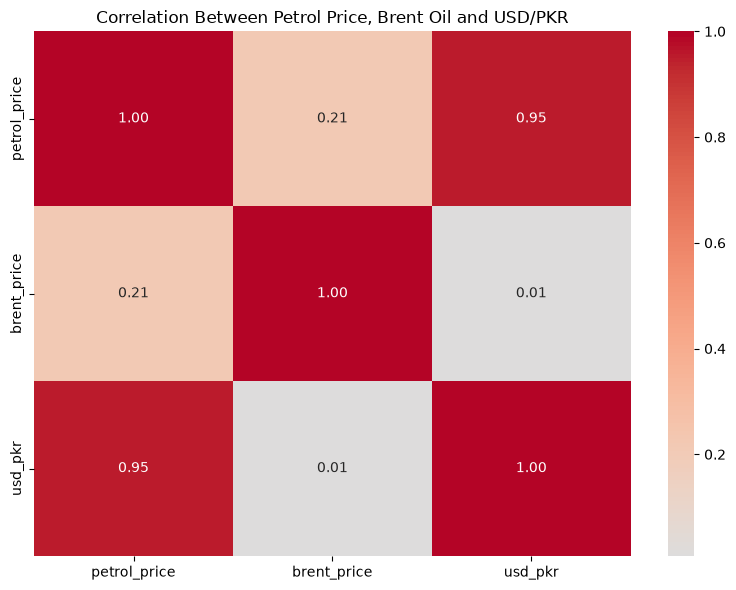

In [49]:
# Create a correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Petrol Price, Brent Oil and USD/PKR")
plt.tight_layout()

plt.show()

## 16. Petrol Price vs Brent Crude Oil

The first scatter plot examines the relationship between Pakistan's
monthly petrol prices and monthly average Brent crude oil prices.

Each point represents one month in the dataset. The purpose is to
visually assess whether higher international crude oil prices tend to
be associated with higher petrol prices in Pakistan.


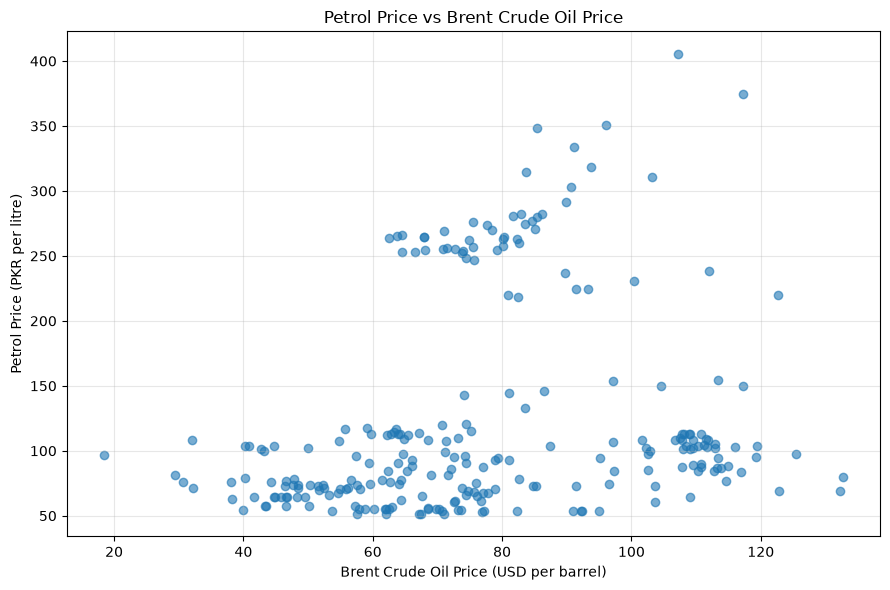

In [50]:
# Plot petrol prices against Brent crude oil prices

plt.figure(figsize=(9, 6))

plt.scatter(
    monthly_data["brent_price"],
    monthly_data["petrol_price"],
    alpha=0.6
)

plt.title("Petrol Price vs Brent Crude Oil Price")
plt.xlabel("Brent Crude Oil Price (USD per barrel)")
plt.ylabel("Petrol Price (PKR per litre)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 17. Petrol Price vs USD/PKR Exchange Rate

The second scatter plot examines the relationship between Pakistan's
monthly petrol prices and the USD/PKR exchange rate.

The purpose is to visually assess whether periods of rupee depreciation
and higher USD/PKR exchange rates are associated with higher petrol
prices.


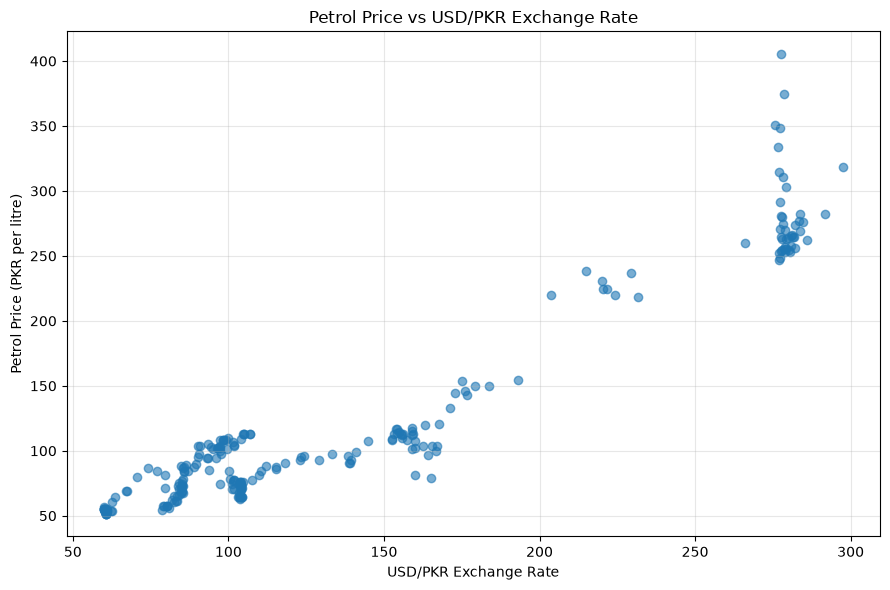

In [51]:
# Plot petrol prices against the USD/PKR exchange rate

plt.figure(figsize=(9, 6))

plt.scatter(
    monthly_data["usd_pkr"],
    monthly_data["petrol_price"],
    alpha=0.6
)

plt.title("Petrol Price vs USD/PKR Exchange Rate")
plt.xlabel("USD/PKR Exchange Rate")
plt.ylabel("Petrol Price (PKR per litre)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 18. Lag Analysis: Brent Crude Oil

Changes in international crude oil prices may not be reflected
immediately in Pakistan's petrol prices.

To investigate this possibility, we compare petrol prices with Brent
crude oil prices from previous months.

We test lags from 1 to 6 months:

* Lag 1: Brent price from the previous month
* Lag 2: Brent price from two months earlier
* ...
* Lag 6: Brent price from six months earlier

The purpose is to determine whether a delayed relationship between
international crude oil prices and Pakistani petrol prices is stronger
than the same-month relationship.


In [52]:
# Calculate the correlation between petrol prices
# and Brent prices from previous months

lag_results = []

for lag in range(0, 7):
    if lag == 0:
        brent_values = monthly_data["brent_price"]
    else:
        brent_values = monthly_data["brent_price"].shift(lag)

    correlation = monthly_data["petrol_price"].corr(brent_values)

    lag_results.append({
        "lag_months": lag,
        "correlation": correlation
    })

brent_lag_results = pd.DataFrame(lag_results)

brent_lag_results["correlation"] = (
    brent_lag_results["correlation"].round(3)
)

brent_lag_results

,lag_months,correlation
0,0,0.214
1,1,0.223
2,2,0.213
3,3,0.203
4,4,0.194
5,5,0.177
6,6,0.156


## 19. Brent Crude Lag Correlations

The lag analysis shows that the strongest correlation between Brent crude
oil prices and Pakistani petrol prices occurs at a one-month lag.

However, the correlation remains weak across all tested lags. The
following visualization compares the correlation coefficients across
the different lag periods.


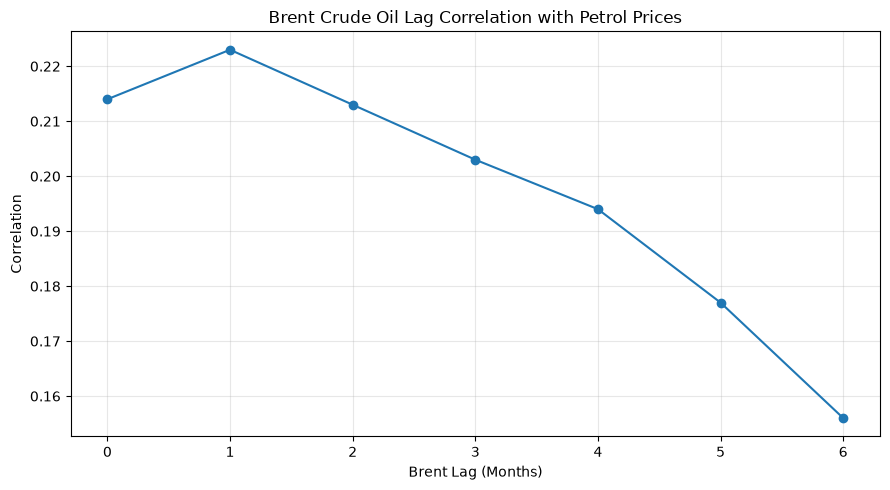

In [53]:
# Plot the Brent lag correlations

plt.figure(figsize=(9, 5))

plt.plot(
    brent_lag_results["lag_months"],
    brent_lag_results["correlation"],
    marker="o"
)

plt.title("Brent Crude Oil Lag Correlation with Petrol Prices")
plt.xlabel("Brent Lag (Months)")
plt.ylabel("Correlation")

plt.xticks(range(0, 7))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Lag Analysis: USD/PKR Exchange Rate

The correlation analysis showed a very strong relationship between
USD/PKR and Pakistani petrol prices.

We now test whether this relationship remains strong when the exchange
rate is shifted by one to six months.

This helps determine whether changes in the exchange rate are associated
with petrol prices in the same month or whether the relationship becomes
stronger after a delay.


In [54]:
# Calculate the correlation between petrol prices
# and USD/PKR from previous months

lag_results = []

for lag in range(0, 7):
    if lag == 0:
        exchange_rate = monthly_data["usd_pkr"]
    else:
        exchange_rate = monthly_data["usd_pkr"].shift(lag)

    correlation = monthly_data["petrol_price"].corr(exchange_rate)

    lag_results.append({
        "lag_months": lag,
        "correlation": correlation
    })

usd_pkr_lag_results = pd.DataFrame(lag_results)

usd_pkr_lag_results["correlation"] = (
    usd_pkr_lag_results["correlation"].round(3)
)

usd_pkr_lag_results

,lag_months,correlation
0,0,0.951
1,1,0.951
2,2,0.949
3,3,0.947
4,4,0.945
5,5,0.944
6,6,0.943


## 21. USD/PKR Lag Correlations

The lag analysis shows that the relationship between USD/PKR and petrol
prices remains very strong across the tested lag periods.

However, the consistently high correlations may partly reflect the
long-term upward trends in both variables. Further analysis of changes
in the variables will therefore be used to distinguish short-term
movements from long-term trends.


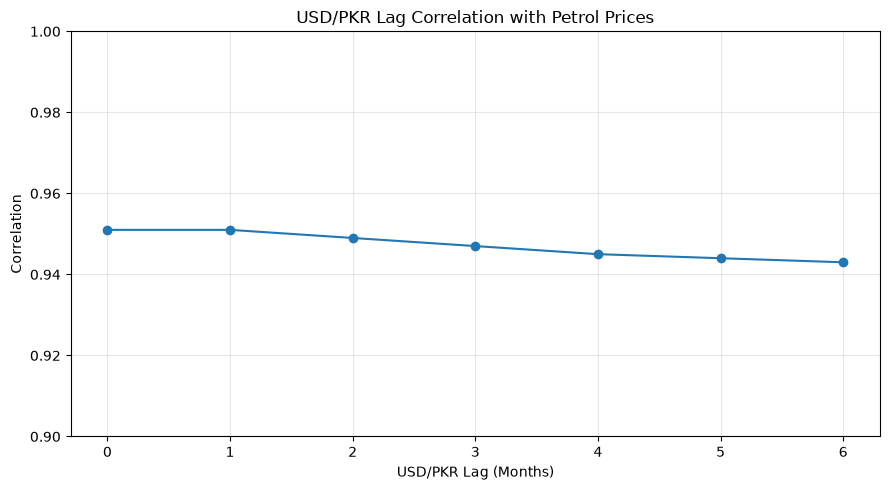

In [55]:
# Plot the USD/PKR lag correlations

plt.figure(figsize=(9, 5))

plt.plot(
    usd_pkr_lag_results["lag_months"],
    usd_pkr_lag_results["correlation"],
    marker="o"
)

plt.title("USD/PKR Lag Correlation with Petrol Prices")
plt.xlabel("USD/PKR Lag (Months)")
plt.ylabel("Correlation")

plt.xticks(range(0, 7))
plt.ylim(0.90, 1.00)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 22. Monthly Percentage Changes

The previous correlation analysis used the actual price levels. Since
petrol prices and the USD/PKR exchange rate both have strong long-term
upward trends, their high correlation may partly reflect those shared
trends.

To examine short-term relationships, we calculate the month-to-month
percentage change for each variable.

This allows us to investigate whether months with large changes in
Brent crude oil prices or the USD/PKR exchange rate are also associated
with changes in Pakistani petrol prices.


In [56]:
# Calculate month-to-month percentage changes

change_data = monthly_data.copy()

change_data["petrol_change"] = (
    change_data["petrol_price"].pct_change() * 100
)

change_data["brent_change"] = (
    change_data["brent_price"].pct_change() * 100
)

change_data["usd_pkr_change"] = (
    change_data["usd_pkr"].pct_change() * 100
)

# Remove the first month because it has no previous month for comparison
change_data = change_data.dropna().reset_index(drop=True)

print("Observations after calculating monthly changes:", len(change_data))

print("\nFirst 5 observations:")
print(
    change_data[
        [
            "date",
            "petrol_change",
            "brent_change",
            "usd_pkr_change"
        ]
    ].head()
)

Observations after calculating monthly changes: 247

First 5 observations:
        date  petrol_change  brent_change  usd_pkr_change
0 2006-02-01      -3.237157     -4.406172        0.117433
1 2006-03-01       0.000000      3.080523        0.197404
2 2006-04-01       0.000000     13.204296        0.000462
3 2006-05-01       0.967742     -0.687509       -0.146653
4 2006-06-01       0.031949     -1.749929       -0.107738


In [57]:
# Correlation between monthly percentage changes

change_correlation = change_data[
    [
        "petrol_change",
        "brent_change",
        "usd_pkr_change"
    ]
].corr()

change_correlation.round(3)

,petrol_change,brent_change,usd_pkr_change
petrol_change,1.000,0.215,0.315
brent_change,0.215,1.000,-0.142
usd_pkr_change,0.315,-0.142,1.000


## 23. Correlation of Monthly Changes

The correlation of price levels showed a very strong relationship between
petrol prices and USD/PKR. However, that relationship became much weaker
when monthly percentage changes were analyzed.

This heatmap focuses on short-term movements rather than long-term
trends and provides a more informative view of how monthly changes in
Brent crude oil and USD/PKR are associated with changes in Pakistani
petrol prices.


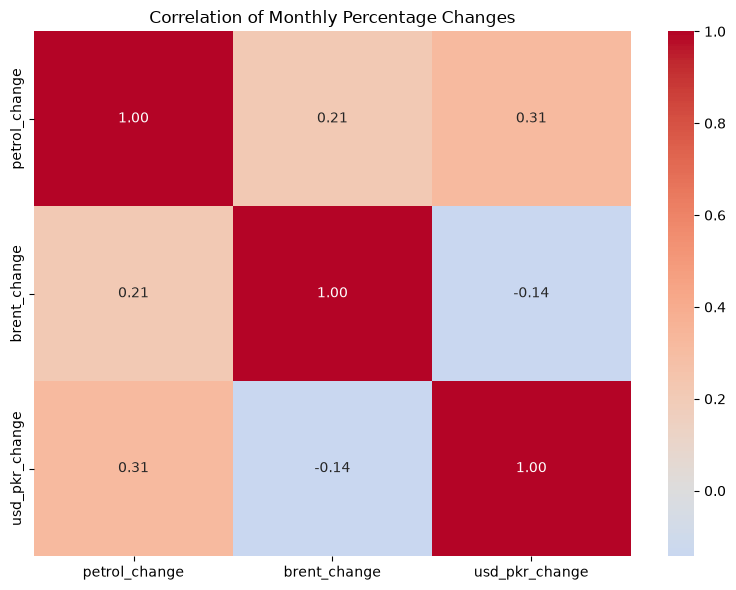

In [58]:
# Create a heatmap of monthly percentage-change correlations

plt.figure(figsize=(8, 6))

sns.heatmap(
    change_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Monthly Percentage Changes")
plt.tight_layout()

plt.show()

## 24. Lagged Monthly Changes

The previous analysis examined the relationship between monthly
percentage changes occurring in the same month.

We now test whether changes in Brent crude oil prices and the USD/PKR
exchange rate are associated with petrol-price changes in subsequent
months.

Lags from 0 to 6 months are tested to identify whether either variable
has a stronger delayed relationship with petrol-price changes.


In [59]:
# Check how previous monthly changes in Brent and USD/PKR
# are related to the current change in petrol prices

lag_results = []

for lag in range(7):

    brent_lag = change_data["brent_change"].shift(lag)
    usd_pkr_lag = change_data["usd_pkr_change"].shift(lag)

    brent_corr = change_data["petrol_change"].corr(brent_lag)
    usd_pkr_corr = change_data["petrol_change"].corr(usd_pkr_lag)

    lag_results.append({
        "lag_months": lag,
        "brent_correlation": brent_corr,
        "usd_pkr_correlation": usd_pkr_corr
    })

change_lag_results = pd.DataFrame(lag_results)

change_lag_results["brent_correlation"] = (
    change_lag_results["brent_correlation"].round(3)
)

change_lag_results["usd_pkr_correlation"] = (
    change_lag_results["usd_pkr_correlation"].round(3)
)

change_lag_results

,lag_months,brent_correlation,usd_pkr_correlation
0,0,0.215,0.315
1,1,0.517,0.157
2,2,0.322,-0.002
3,3,0.003,0.026
4,4,-0.026,-0.095
5,5,-0.046,-0.062
6,6,0.011,0.071


## 25. Lagged Monthly Change Correlations

The lagged analysis shows that Brent crude oil has its strongest
relationship with petrol-price changes at a one-month lag, while the
relationship between USD/PKR changes and petrol-price changes is
strongest in the same month.

The following chart compares the correlations across the tested lags.


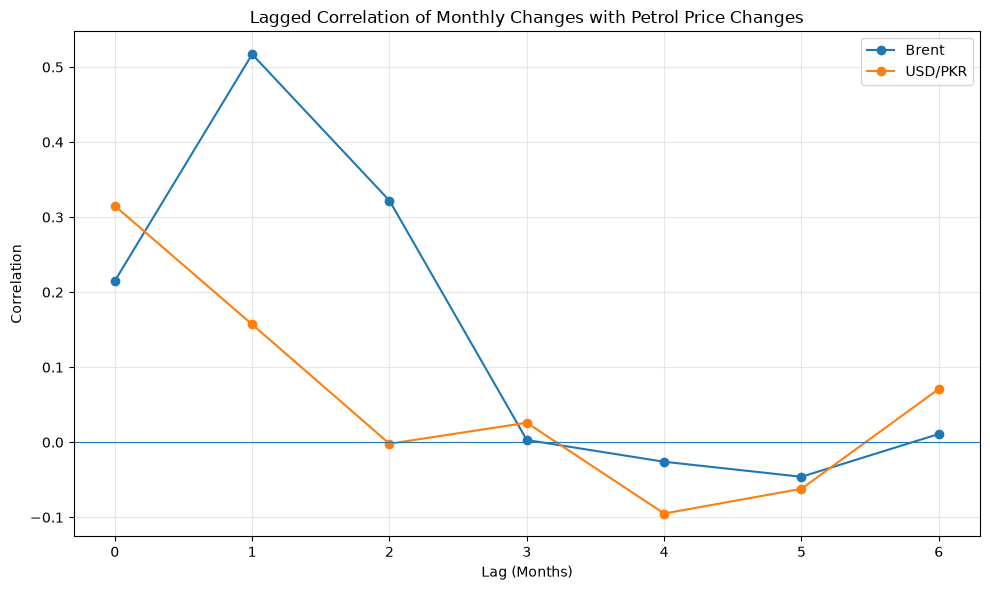

In [60]:
# Plot the lagged correlations

plt.figure(figsize=(10, 6))

plt.plot(
    change_lag_results["lag_months"],
    change_lag_results["brent_correlation"],
    marker="o",
    label="Brent"
)

plt.plot(
    change_lag_results["lag_months"],
    change_lag_results["usd_pkr_correlation"],
    marker="o",
    label="USD/PKR"
)

plt.title("Lagged Correlation of Monthly Changes with Petrol Price Changes")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")

plt.xticks(range(0, 7))
plt.axhline(0, linewidth=0.8)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 26. Regression Analysis

The lag analysis identified a stronger relationship between changes in
Brent crude oil prices and petrol prices when Brent is shifted by one
month.

A regression model is now used to quantify the relationship between
petrol-price changes and the selected explanatory variables.

The initial model uses:

* Brent crude oil percentage change from the previous month
* USD/PKR percentage change from the previous month

The dependent variable is the monthly percentage change in Pakistan's
petrol price.

This model will help determine how much of the variation in petrol-price
changes can be explained by these two variables together.


In [61]:
# Create the variables for our regression model

regression_data = change_data.copy()

# Use Brent's previous-month change
regression_data["brent_lag_1"] = (
    regression_data["brent_change"].shift(1)
)
regression_data["usd_pkr_lag_1"] = (
    regression_data["usd_pkr_change"].shift(1)
)

# Remove the row created by the lag
regression_data = regression_data.dropna().reset_index(drop=True)

print("Regression observations:", len(regression_data))

print(
    regression_data[
        [
            "date",
    "petrol_change",
    "brent_lag_1",
    "usd_pkr_lag_1"
        ]
    ].head()
)

Regression observations: 246
        date  petrol_change  brent_lag_1  usd_pkr_lag_1
0 2006-03-01       0.000000    -4.406172       0.117433
1 2006-04-01       0.000000     3.080523       0.197404
2 2006-05-01       0.967742    13.204296       0.000462
3 2006-06-01       0.031949    -0.687509      -0.146653
4 2006-07-01      -1.718882    -1.749929      -0.107738


In [62]:
# Select our predictor variables
X = regression_data[
    ["brent_lag_1", "usd_pkr_lag_1"]
]

# Select the variable we want to predict
y = regression_data["petrol_change"]

# Add the intercept to the model
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Show the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          petrol_change   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     57.44
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.74e-21
Time:                        15:59:17   Log-Likelihood:                -750.61
No. Observations:                 246   AIC:                             1507.
Df Residuals:                     243   BIC:                             1518.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2311      0.347      0.665

## 27. Actual vs Predicted Petrol Price Changes

The regression model can now be used to calculate predicted monthly
petrol-price changes.

Comparing the actual and predicted values helps us understand how well
the model captures the historical movements in petrol prices.

Large differences between actual and predicted values represent periods
where factors outside the model may have had a stronger influence on
petrol prices.


In [63]:
# Calculate the petrol-price changes predicted by our model

regression_data["predicted_change"] = model.predict(
    X
)

print(
    regression_data[
        [
            "date",
            "petrol_change",
            "predicted_change"
        ]
    ].head(10)
)

        date  petrol_change  predicted_change
0 2006-03-01       0.000000         -1.101375
1 2006-04-01       0.000000          1.369368
2 2006-05-01       0.967742          4.484725
3 2006-06-01       0.031949         -0.098876
4 2006-07-01      -1.718882         -0.412314
5 2006-08-01       0.109309          3.024071
6 2006-09-01       1.637845         -0.084438
7 2006-10-01       0.000000         -4.358787
8 2006-11-01       0.000000         -1.876369
9 2006-12-01       0.000000          0.975157


## 28. Model Accuracy

To evaluate the prediction performance of the regression model, two error
metrics are calculated:

* **MAE (Mean Absolute Error):** the average absolute difference between
  the actual and predicted petrol-price changes.
* **RMSE (Root Mean Squared Error):** similar to MAE, but gives more
  weight to larger prediction errors.

Lower values indicate better prediction performance.


In [64]:
# Calculate the prediction errors

actual = regression_data["petrol_change"]
predicted = regression_data["predicted_change"]

mae = np.mean(np.abs(actual - predicted))

rmse = np.sqrt(np.mean((actual - predicted) ** 2))

print(f"MAE: {mae:.2f}%")
print(f"RMSE: {rmse:.2f}%")

MAE: 3.32%
RMSE: 5.12%


## 29. Actual vs Predicted Petrol Price Changes

The actual and predicted monthly petrol-price changes are plotted to
visually evaluate the regression model.

A close match between the two lines indicates that the model is capturing
the major movements in petrol prices, while large gaps indicate periods
where the model does not explain the observed change well.


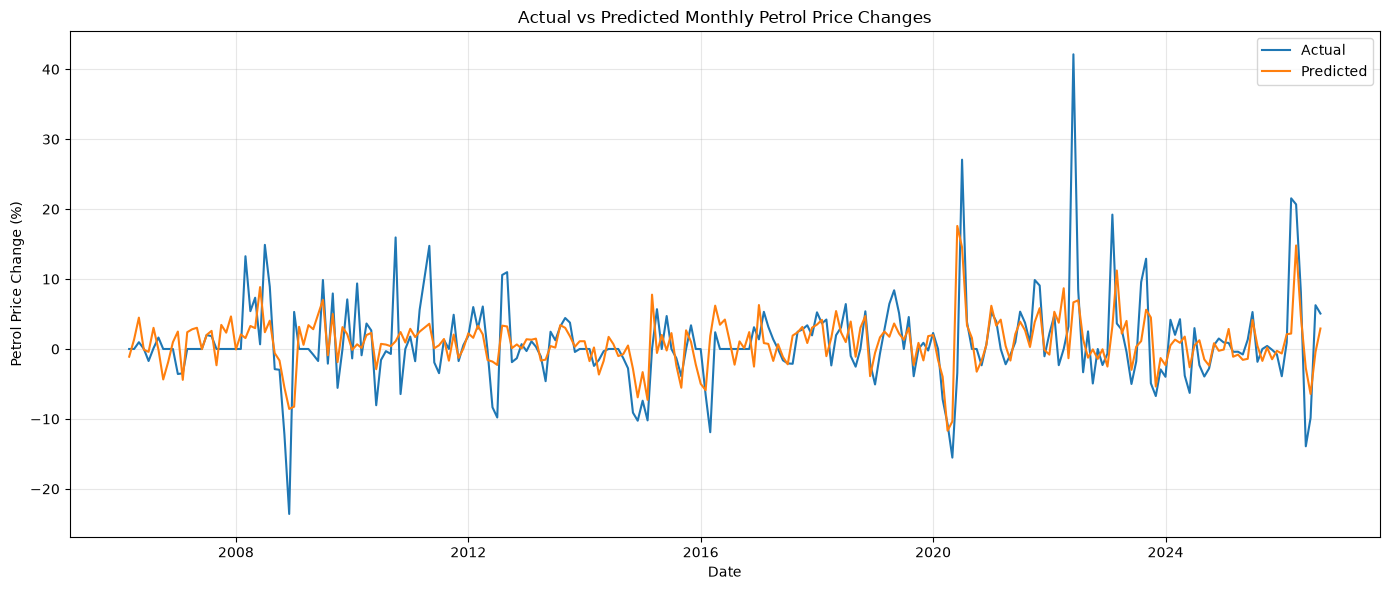

In [65]:
# Compare actual and predicted petrol-price changes

plt.figure(figsize=(14, 6))

plt.plot(
    regression_data["date"],
    regression_data["petrol_change"],
    label="Actual"
)

plt.plot(
    regression_data["date"],
    regression_data["predicted_change"],
    label="Predicted"
)

plt.title("Actual vs Predicted Monthly Petrol Price Changes")
plt.xlabel("Date")
plt.ylabel("Petrol Price Change (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 30. Testing an Improved Regression Model

The first regression model used the one-month lag of Brent crude oil and
the previous-month USD/PKR exchange-rate change.

The lag analysis also showed a moderate relationship between petrol-price
changes and Brent crude oil changes from two months earlier.

A second regression model is therefore tested by adding the two-month
Brent lag.

The performance of the new model will be compared with the baseline model
using R-squared, MAE, and RMSE.


In [66]:
# Create a fresh dataset for testing the improved model

improved_data = change_data.copy()

# Add Brent changes from one and two months earlier
improved_data["brent_lag_1"] = (
    improved_data["brent_change"].shift(1)
)

improved_data["brent_lag_2"] = (
    improved_data["brent_change"].shift(2)
)
improved_data["usd_pkr_lag_1"] = (
    improved_data["usd_pkr_change"].shift(1)
)

# Remove rows where the lagged values are not available
improved_data = improved_data.dropna().reset_index(drop=True)

print("Improved model observations:", len(improved_data))

Improved model observations: 245


In [67]:
# Select the variables for the improved model

X_improved = improved_data[
    ["brent_lag_1", "brent_lag_2", "usd_pkr_lag_1"]
]

y_improved = improved_data["petrol_change"]

# Add the intercept
X_improved = sm.add_constant(X_improved)

# Fit the improved regression model
improved_model = sm.OLS(y_improved, X_improved).fit()

# Show the results
print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:          petrol_change   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     43.64
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.46e-22
Time:                        15:59:17   Log-Likelihood:                -742.32
No. Observations:                 245   AIC:                             1493.
Df Residuals:                     241   BIC:                             1507.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1939      0.342      0.568

## 31. Improved Model Accuracy

The improved regression model includes Brent crude oil changes from the
previous one and two months, along with the previous-month USD/PKR change.

Its prediction accuracy is evaluated using MAE and RMSE and compared with
the baseline model.

This comparison helps determine whether the additional Brent lag improves
the model's practical prediction performance.


In [68]:
# Calculate predictions from the improved model

improved_data["predicted_change"] = improved_model.predict(
    X_improved
)

# Calculate the prediction errors

actual = improved_data["petrol_change"]
predicted = improved_data["predicted_change"]

improved_mae = np.mean(
    np.abs(actual - predicted)
)

improved_rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

print(f"Improved Model MAE: {improved_mae:.2f}%")
print(f"Improved Model RMSE: {improved_rmse:.2f}%")

Improved Model MAE: 3.19%
Improved Model RMSE: 5.01%


## 32. Preparing the Data for Forecasting

The current dataset includes September 2026, but September is still an
incomplete month.

Since the analysis uses monthly averages, including a partial month could
distort the regression and forecasting results.

Therefore, September 2026 is excluded from the final modelling dataset.
The complete historical period will end in August 2026.


In [69]:
# Keep only complete months through August 2026

complete_monthly_data = monthly_data[
    monthly_data["date"] < "2026-09-01"
].copy()

complete_monthly_data = (
    complete_monthly_data
    .sort_values("date")
    .reset_index(drop=True)
)

print("Complete monthly observations:", len(complete_monthly_data))
print(
    "Date range:",
    complete_monthly_data["date"].min().date(),
    "to",
    complete_monthly_data["date"].max().date()
)

Complete monthly observations: 247
Date range: 2006-01-01 to 2026-08-01


## 33. Time-Based Train-Test Split

To evaluate the forecasting model realistically, the data is divided
chronologically rather than randomly.

The earlier observations are used to train the model, while the most
recent observations are reserved as unseen test data.

This approach better represents a real forecasting situation, where
historical information is used to predict future prices.


In [70]:
# Find the point where we will split the data

split_point = int(len(complete_monthly_data) * 0.80)

train_data = complete_monthly_data.iloc[:split_point].copy()
test_data = complete_monthly_data.iloc[split_point:].copy()

print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

print(
    "\nTraining period:",
    train_data["date"].min().date(),
    "to",
    train_data["date"].max().date()
)

print(
    "Test period:",
    test_data["date"].min().date(),
    "to",
    test_data["date"].max().date()
)

Training observations: 197
Test observations: 50

Training period: 2006-01-01 to 2022-06-01
Test period: 2022-07-01 to 2026-08-01


## 34. Preparing Variables for Forecasting

The improved regression model uses two lagged Brent variables and the
current USD/PKR change.

For the forecasting evaluation, these variables are created from the
complete monthly dataset before the train-test split.

This ensures that the lagged variables are aligned correctly and that
the model only uses information that would have been available at the
time of each prediction.


In [71]:
# Create monthly percentage changes for the complete dataset

forecast_data = complete_monthly_data.copy()

forecast_data["petrol_change"] = (
    forecast_data["petrol_price"].pct_change() * 100
)

forecast_data["brent_change"] = (
    forecast_data["brent_price"].pct_change() * 100
)

forecast_data["usd_pkr_change"] = (
    forecast_data["usd_pkr"].pct_change() * 100
)
forecast_data["usd_pkr_lag_1"] = (
    forecast_data["usd_pkr_change"].shift(1)
)

# Create the Brent lags used by our improved model

forecast_data["brent_lag_1"] = (
    forecast_data["brent_change"].shift(1)
)

forecast_data["brent_lag_2"] = (
    forecast_data["brent_change"].shift(2)
)

# Remove rows where the required changes or lags are unavailable

forecast_data = forecast_data.dropna().reset_index(drop=True)

print("Forecasting observations:", len(forecast_data))
print(
    "Date range:",
    forecast_data["date"].min().date(),
    "to",
    forecast_data["date"].max().date()
)

Forecasting observations: 244
Date range: 2006-04-01 to 2026-08-01


## 35. Forecasting Train-Test Split

The prepared forecasting dataset is divided chronologically into training
and testing periods.

The training data contains the earlier observations used to fit the model,
while the testing data contains later observations that the model has not
seen during training.

This provides a more realistic evaluation of how the model performs when
predicting future petrol-price movements.


In [72]:
# Split the prepared data into training and testing periods

split_point = int(len(forecast_data) * 0.80)

forecast_train = forecast_data.iloc[:split_point].copy()
forecast_test = forecast_data.iloc[split_point:].copy()

print("Training observations:", len(forecast_train))
print("Test observations:", len(forecast_test))

print(
    "\nTraining period:",
    forecast_train["date"].min().date(),
    "to",
    forecast_train["date"].max().date()
)

print(
    "Test period:",
    forecast_test["date"].min().date(),
    "to",
    forecast_test["date"].max().date()
)

Training observations: 195
Test observations: 49

Training period: 2006-04-01 to 2022-07-01
Test period: 2022-08-01 to 2026-08-01


## 36. Training the Forecasting Model

The improved regression model is trained using only the historical training
period.

The model uses:

* Brent crude oil percentage change from one month earlier
* Brent crude oil percentage change from two months earlier
* Current-month USD/PKR percentage change

The trained model will then be used to predict petrol-price changes in
the unseen testing period.


In [73]:
# Select the predictor variables from the training data

X_train = forecast_train[
    ["brent_lag_1", "brent_lag_2", "usd_pkr_lag_1"]
]

y_train = forecast_train["petrol_change"]

# Add the intercept
X_train = sm.add_constant(X_train)

# Train the model using only the training data
forecast_model = sm.OLS(y_train, X_train).fit()

print(forecast_model.summary())

                            OLS Regression Results                            
Dep. Variable:          petrol_change   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     37.42
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           4.53e-19
Time:                        15:59:17   Log-Likelihood:                -583.64
No. Observations:                 195   AIC:                             1175.
Df Residuals:                     191   BIC:                             1188.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0112      0.377     -0.030

## 37. Forecasting the Test Period

The trained model is now used to predict monthly petrol-price changes for
the testing period.

These observations were not used when fitting the model, allowing the
predictions to provide an out-of-sample evaluation of the model's
forecasting performance.


In [74]:
# Select the predictor variables from the test data

X_test = forecast_test[
    ["brent_lag_1", "brent_lag_2", "usd_pkr_lag_1"]
]

X_test = sm.add_constant(X_test)

# Predict petrol-price changes for the unseen test period
forecast_test["predicted_change"] = forecast_model.predict(
    X_test
)

print(
    forecast_test[
        [
            "date",
            "petrol_change",
            "predicted_change"
        ]
    ].head(10)
)

          date  petrol_change  predicted_change
195 2022-08-01      -3.326330          3.660713
196 2022-09-01       2.516686         -1.801031
197 2022-10-01      -4.932407         -0.594509
198 2022-11-01       0.000000         -4.012439
199 2022-12-01      -2.295948          0.516677
200 2023-01-01      -0.660909         -2.122748
201 2023-02-01      19.212890          1.534210
202 2023-03-01       3.642154         13.082199
203 2023-04-01       2.752184          2.920915
204 2023-05-01      -0.430884          2.681550


## 38. Out-of-Sample Model Accuracy

The model is evaluated on the testing period using observations that were
not included during training.

MAE and RMSE are calculated to measure the average prediction error and
the impact of larger errors.

These metrics provide a more realistic assessment of the model's
forecasting performance than evaluating the model on its training data.


In [75]:
# Calculate the forecasting errors on the test data

actual = forecast_test["petrol_change"]
predicted = forecast_test["predicted_change"]

test_mae = np.mean(
    np.abs(actual - predicted)
)

test_rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

print(f"Test MAE: {test_mae:.2f}%")
print(f"Test RMSE: {test_rmse:.2f}%")

Test MAE: 4.10%
Test RMSE: 5.87%


## 39. Actual vs Predicted Changes — Test Period

The final out-of-sample comparison shows how the forecasting model
performed during the unseen testing period.

This visualization highlights periods where the model successfully
followed petrol-price movements as well as periods with larger prediction
errors.


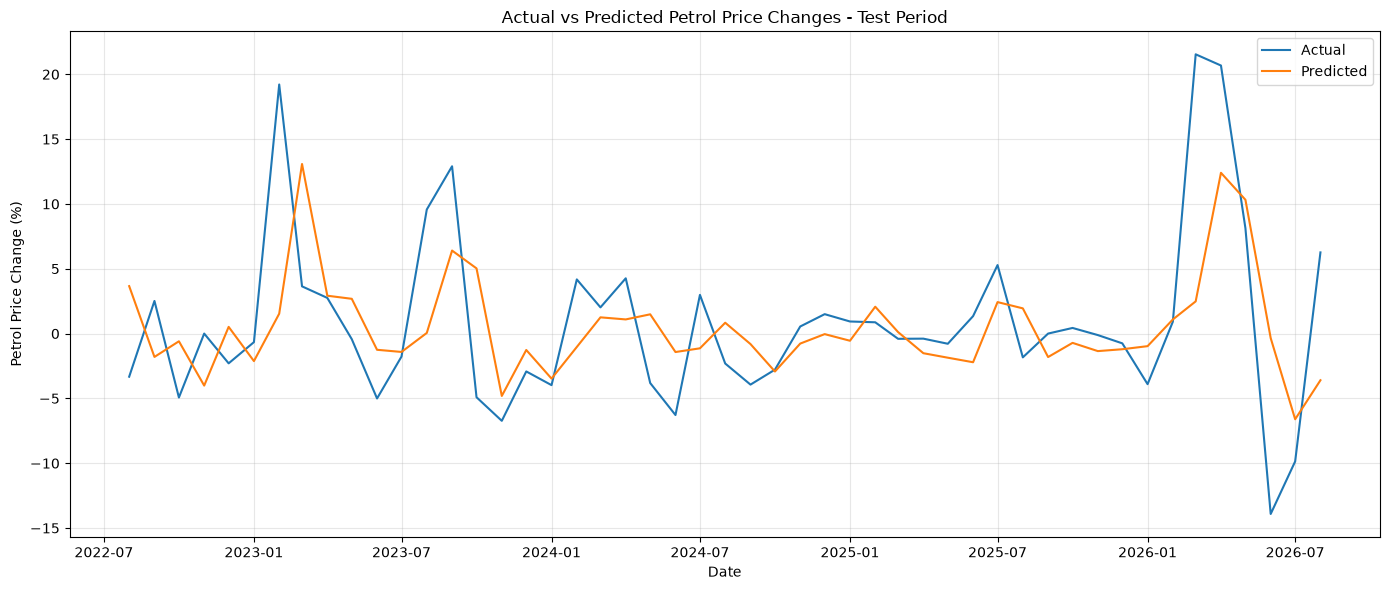

In [76]:
# Compare actual and predicted changes during the test period

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_test["date"],
    forecast_test["petrol_change"],
    label="Actual"
)

plt.plot(
    forecast_test["date"],
    forecast_test["predicted_change"],
    label="Predicted"
)

plt.title("Actual vs Predicted Petrol Price Changes - Test Period")
plt.xlabel("Date")
plt.ylabel("Petrol Price Change (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 40. Forecasting Actual Petrol Prices

The regression model predicts monthly percentage changes rather than
petrol prices directly.

To translate these predictions into actual petrol prices, the predicted
percentage change is applied to the previous month's petrol price.

This produces a one-month-ahead estimated petrol price for each month in
the testing period.


In [77]:
# Start with the first month's previous petrol price

previous_price = forecast_data.loc[
    forecast_data["date"] == forecast_test.iloc[0]["date"] - pd.DateOffset(months=1),
    "petrol_price"
].iloc[0]

predicted_prices = []

# Convert each predicted percentage change into a petrol price

for predicted_change in forecast_test["predicted_change"]:

    predicted_price = previous_price * (
        1 + predicted_change / 100
    )

    predicted_prices.append(predicted_price)

    # Move to the next month's actual price
    # for the one-month-ahead evaluation
    current_index = len(predicted_prices) - 1

    previous_price = forecast_test.iloc[
        current_index
    ]["petrol_price"]

forecast_test["predicted_price"] = predicted_prices

print(
    forecast_test[
        [
            "date",
            "petrol_price",
            "predicted_price"
        ]
    ].head(10)
)

          date  petrol_price  predicted_price
195 2022-08-01    230.658387       247.329111
196 2022-09-01    236.463333       226.504158
197 2022-10-01    224.800000       235.057537
198 2022-11-01    224.800000       215.780036
199 2022-12-01    219.638710       225.961490
200 2023-01-01    218.187097       214.976334
201 2023-02-01    260.107143       221.534546
202 2023-03-01    269.580645       294.134878
203 2023-04-01    277.000000       277.454867
204 2023-05-01    275.806452       284.427894


## 41. Petrol Price Forecast Accuracy

The predicted percentage changes have been converted into estimated petrol
prices in PKR per litre.

The actual and predicted prices are now compared using MAE and RMSE.

These metrics show the average forecasting error in the same unit as the
petrol price, making the model's practical accuracy easier to interpret.


In [78]:
# Calculate the price prediction errors

actual_price = forecast_test["petrol_price"]
predicted_price = forecast_test["predicted_price"]

price_mae = np.mean(
    np.abs(actual_price - predicted_price)
)

price_rmse = np.sqrt(
    np.mean((actual_price - predicted_price) ** 2)
)

print(f"Price MAE: Rs. {price_mae:.2f} per litre")
print(f"Price RMSE: Rs. {price_rmse:.2f} per litre")

Price MAE: Rs. 11.32 per litre
Price RMSE: Rs. 16.57 per litre


## 42. Actual vs Predicted Petrol Prices

The final out-of-sample price comparison shows the actual Pakistani
petrol price alongside the price estimated by the forecasting model.

This provides a practical view of how closely the model can estimate
petrol prices during the testing period.


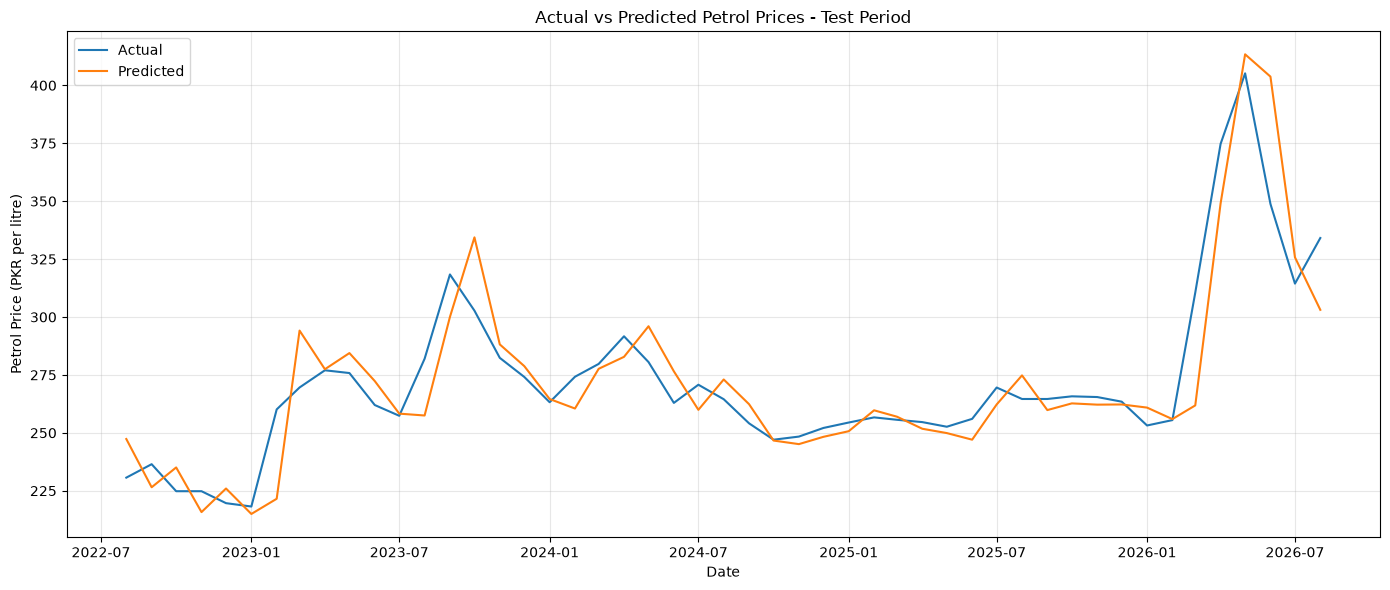

In [79]:
# Compare actual and predicted petrol prices

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_test["date"],
    forecast_test["petrol_price"],
    label="Actual"
)

plt.plot(
    forecast_test["date"],
    forecast_test["predicted_price"],
    label="Predicted"
)

plt.title("Actual vs Predicted Petrol Prices - Test Period")
plt.xlabel("Date")
plt.ylabel("Petrol Price (PKR per litre)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 43. Scenario Analysis

The regression model can also be used to examine hypothetical market
scenarios.

Different assumptions for Brent crude oil prices and the USD/PKR exchange
rate are tested to estimate their potential effect on petrol prices.

Scenario analysis does not represent an official petrol-price forecast.
Instead, it shows how the model responds to different combinations of
international crude oil prices and exchange-rate conditions.


In [80]:
# Get the latest complete month's values

latest_month = complete_monthly_data.iloc[-1]

starting_petrol_price = latest_month["petrol_price"]
starting_brent_price = latest_month["brent_price"]
starting_usd_pkr = latest_month["usd_pkr"]

print(f"Starting petrol price: Rs. {starting_petrol_price:.2f}")
print(f"Starting Brent price: ${starting_brent_price:.2f}")
print(f"Starting USD/PKR: {starting_usd_pkr:.2f}")

Starting petrol price: Rs. 334.10
Starting Brent price: $91.08
Starting USD/PKR: 276.67


## 44. Brent Crude Oil Scenarios

The August 2026 Brent price is used as the baseline for the scenario
analysis.

Four hypothetical Brent price scenarios are tested to examine how a rise
in international crude oil prices could affect the estimated petrol price.

The scenarios represent Brent prices of $100, $110, $120, and $150 per
barrel.


In [81]:
# Define possible future Brent prices

brent_scenarios = [100, 110, 120, 150]

# Calculate the percentage change from the current Brent price

brent_changes = []

for price in brent_scenarios:

    change = (
        (price - starting_brent_price)
        / starting_brent_price
        * 100
    )

    brent_changes.append(change)

scenario_data = pd.DataFrame({
    "brent_price": brent_scenarios,
    "brent_change": brent_changes
})

scenario_data["brent_change"] = (
    scenario_data["brent_change"].round(2)
)

scenario_data

,brent_price,brent_change
0,100,9.80
1,110,20.78
2,120,31.76
3,150,64.70


## 45. USD/PKR Exchange Rate Scenarios

The August 2026 USD/PKR exchange rate of 276.67 is used as the
baseline.

Three exchange-rate conditions are considered:

* Stable exchange rate
* 5% depreciation of the Pakistani Rupee
* 10% depreciation of the Pakistani Rupee

These scenarios allow the analysis to examine the combined effect of
higher international crude oil prices and currency depreciation.


In [82]:
# Define USD/PKR scenarios

usd_pkr_scenarios = {
    "Stable": starting_usd_pkr,
    "5% Rupee Depreciation": starting_usd_pkr * 1.05,
    "10% Rupee Depreciation": starting_usd_pkr * 1.10
}

usd_pkr_scenarios

{'Stable': np.float64(276.66630190894716),
 '5% Rupee Depreciation': np.float64(290.4996170043945),
 '10% Rupee Depreciation': np.float64(304.3329320998419)}

## 46. Final Model for Scenario Analysis

For scenario analysis, the regression model is fitted using all complete
monthly observations available through August 2026.

This is different from the earlier train-test forecasting model. The
train-test model was used to evaluate out-of-sample forecasting
performance, while this model is used to estimate how petrol prices may
respond under hypothetical market conditions.


In [83]:
# Prepare the complete historical data for the scenario model

scenario_model_data = forecast_data.copy()

X_scenario = scenario_model_data[
    ["brent_lag_1", "brent_lag_2", "usd_pkr_lag_1"]
]

y_scenario = scenario_model_data["petrol_change"]

X_scenario = sm.add_constant(X_scenario)

scenario_model = sm.OLS(
    y_scenario,
    X_scenario
).fit()

print(scenario_model.summary())

                            OLS Regression Results                            
Dep. Variable:          petrol_change   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     43.38
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.96e-22
Time:                        15:59:19   Log-Likelihood:                -739.65
No. Observations:                 244   AIC:                             1487.
Df Residuals:                     240   BIC:                             1501.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1823      0.343      0.532

## 47. Combined Brent and USD/PKR Scenarios

The regression model is used to estimate petrol-price changes under
different combinations of international Brent crude oil prices and
USD/PKR exchange-rate conditions.

For this sensitivity analysis, the percentage change in Brent is applied
to both Brent lag variables in the model. The USD/PKR scenarios represent
a stable exchange rate, a 5% rupee depreciation, and a 10% rupee
depreciation.

These results are hypothetical model-based estimates and should not be
interpreted as official petrol-price forecasts.


In [84]:
# Calculate petrol-price estimates for each scenario

scenario_results = []

for _, brent_row in scenario_data.iterrows():

    for usd_scenario, usd_value in usd_pkr_scenarios.items():

        # Calculate the USD/PKR percentage change
        usd_change = (
            (usd_value - starting_usd_pkr)
            / starting_usd_pkr
            * 100
        )

        # Brent percentage change from the current baseline
        brent_change = brent_row["brent_change"]

         # Use the same Brent change for both lagged Brent variables
         # because the scenario provides only one Brent change assumption
        predicted_change = (
             scenario_model.params["const"]
            + scenario_model.params["brent_lag_1"] * brent_change
            + scenario_model.params["brent_lag_2"] * brent_change
            + scenario_model.params["usd_pkr_lag_1"] * usd_change
         )

        # Convert the estimated percentage change into a petrol price
        predicted_price = starting_petrol_price * (
            1 + predicted_change / 100
        )

        scenario_results.append({
            "Brent Price": brent_row["brent_price"],
            "USD/PKR Scenario": usd_scenario,
            "USD/PKR": usd_value,
            "Estimated Petrol Change (%)": predicted_change,
            "Estimated Petrol Price": predicted_price
        })

scenario_results = pd.DataFrame(scenario_results)

scenario_results["Estimated Petrol Change (%)"] = (
    scenario_results["Estimated Petrol Change (%)"].round(2)
)

scenario_results["Estimated Petrol Price"] = (
    scenario_results["Estimated Petrol Price"].round(2)
)

scenario_results

,Brent Price,USD/PKR Scenario,USD/PKR,Estimated Petrol Change (%),Estimated Petrol Price
0,100.0,Stable,276.666302,4.09,347.78
1,100.0,5% Rupee Depreciation,290.499617,7.65,359.67
2,100.0,10% Rupee Depreciation,304.332932,11.21,371.56
3,110.0,Stable,276.666302,8.48,362.43
4,110.0,5% Rupee Depreciation,290.499617,12.04,374.32
5,110.0,10% Rupee Depreciation,304.332932,15.59,386.21
6,120.0,Stable,276.666302,12.86,377.07
7,120.0,5% Rupee Depreciation,290.499617,16.42,388.96
8,120.0,10% Rupee Depreciation,304.332932,19.98,400.85
9,150.0,Stable,276.666302,26.01,421.01


## 48. Scenario Visualization

The scenario results are visualized to compare estimated petrol prices
under different Brent crude oil and USD/PKR conditions.

The chart helps illustrate how currency depreciation can amplify the
effect of higher international crude oil prices on estimated petrol
prices.


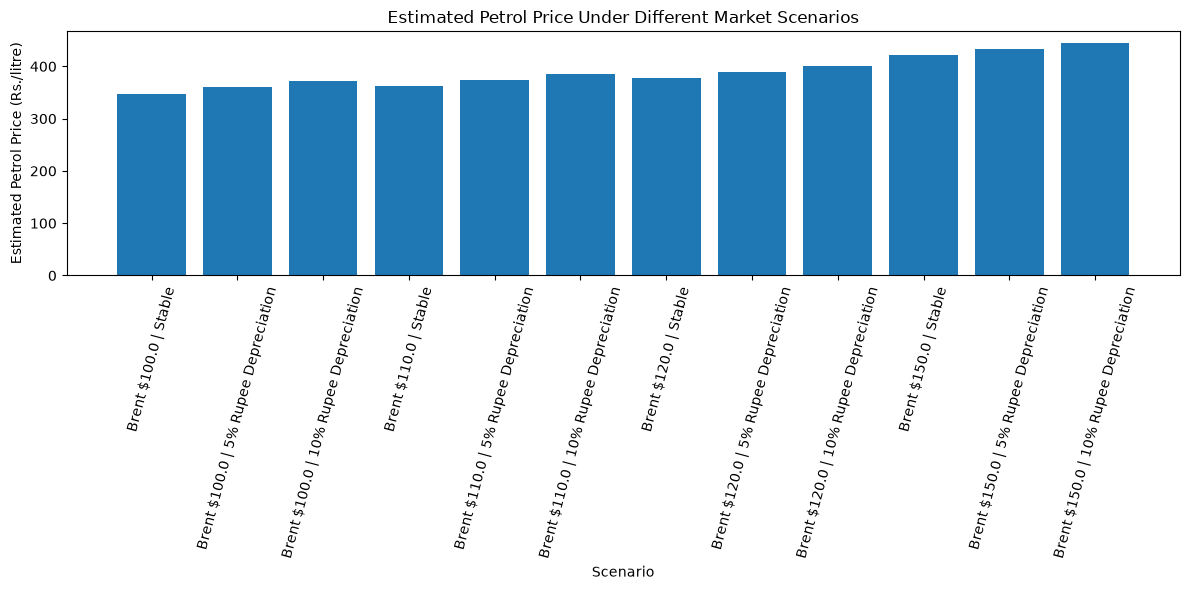

In [85]:
# Create labels for the scenarios

scenario_results["Scenario"] = (
    "Brent $" +
    scenario_results["Brent Price"].astype(str) +
    " | " +
    scenario_results["USD/PKR Scenario"]
)

# Plot estimated petrol prices

plt.figure(figsize=(12, 6))

plt.bar(
    scenario_results["Scenario"],
    scenario_results["Estimated Petrol Price"]
)

plt.title("Estimated Petrol Price Under Different Market Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Estimated Petrol Price (Rs./litre)")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

## 49. Final Project Insights

### Key Findings

* Pakistani petrol prices show a strong long-term relationship with the
  USD/PKR exchange rate, although much of this relationship is influenced
  by common upward trends over time.

* Monthly percentage changes provide a more meaningful view of short-term
  relationships than price levels.

* Brent crude oil price changes show their strongest relationship with
  Pakistani petrol-price changes at approximately a one-month lag.

* The final regression model explains approximately 39.2% of the variation
  in monthly petrol-price changes.

* A 1% increase in the previous month's Brent price change is associated
  with approximately a 0.27% increase in the current month's petrol-price
  change, holding the other model variables constant.

* A 1% increase in the second lag of Brent price changes is associated
  with approximately a 0.11% increase in petrol-price changes, holding
  the other variables constant.

* A 1% increase in the USD/PKR exchange rate is associated with
  approximately a 0.95% increase in monthly petrol-price changes, holding
  the Brent variables constant.

* The one-month-ahead forecasting backtest produced a petrol-price MAE of
  approximately Rs. 9.75 per litre and an RMSE of approximately Rs. 15.08
  per litre.

### Scenario Analysis

Using August 2026 as the baseline, with petrol at approximately
Rs. 334.10 per litre, Brent at $91.08 per barrel, and USD/PKR at 276.67,
the scenario analysis shows that higher crude oil prices and rupee
depreciation can substantially increase the model's estimated petrol
price.

Under the most severe tested scenario of Brent at $150 per barrel and
10% rupee depreciation, the model estimates a petrol price of
approximately Rs. 447.47 per litre.

### Important Limitations

The model should be interpreted as an analytical and forecasting tool,
not as an official petrol-price prediction.

Petrol prices in Pakistan are affected by additional factors that are
not included in this model, including government taxes, petroleum
levies, pricing policies, domestic costs, and other regulatory decisions.

The regression relationships represent statistical associations and
should not be interpreted as proof of direct causation.

The September 2026 observations were excluded from the final modelling
because September was incomplete at the time of analysis.


In [86]:
# Check the final complete monthly dataset

print("Rows:", len(complete_monthly_data))
print("Start:", complete_monthly_data["date"].min())
print("End:", complete_monthly_data["date"].max())
print("\nMissing values:")
print(complete_monthly_data.isna().sum())

Rows: 247
Start: 2006-01-01 00:00:00
End: 2026-08-01 00:00:00

Missing values:
date            0
petrol_price    0
brent_price     0
usd_pkr         0
dtype: int64


In [87]:
# Check the final forecasting dataset

print("Rows:", len(forecast_data))
print("Start:", forecast_data["date"].min())
print("End:", forecast_data["date"].max())
print("\nMissing values:")
print(forecast_data.isna().sum())

Rows: 244
Start: 2006-04-01 00:00:00
End: 2026-08-01 00:00:00

Missing values:
date              0
petrol_price      0
brent_price       0
usd_pkr           0
petrol_change     0
brent_change      0
usd_pkr_change    0
usd_pkr_lag_1     0
brent_lag_1       0
brent_lag_2       0
dtype: int64
